In [2]:
## aart_func is a file with the functions for the image generation
from aart_func import *
## params have all the important params of the simulation
from params import *
plt.rcParams['text.usetex'] = True


Thanks for using AART
Copyright (C) 2023, A. Cardenas-Avendano, H. Zhu & A. Lupsasca



In [3]:
import similaritymeasures
import numpy as np
from scipy.integrate import simpson
from scipy.spatial.distance import euclidean
from scipy.interpolate import interp1d
import pandas as pd 
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['text.usetex'] = True  # Si tienes LaTeX instalado
mpl.rcParams['font.family'] = 'serif'

In [5]:
#--------------------------------- Estandarización
def estand(f):
    return (f-np.mean(f))/np.std(f)
#--------------------------------- DISTANCIAS L1 Y L2

def distancia_L2(f, g, x):
    return np.sqrt(simpson((f - g)**2, x))

def distancia_L2_rel(f, g, x):
    num = np.sqrt(simpson((f - g)**2, x))
    den = np.sqrt(simpson(f**2, x))
    return num / den

def distancia_L1(f, g, x):
    return simpson(np.abs(f - g), x)

def distancia_L1_rel(f, g, x):
    num = simpson(np.abs(f - g), x)
    den = simpson(np.abs(f), x)
    return num / den

#----------------------------- CORRELACIÓN DE PEARSON FUNCIONAL

def pearson_funcional(f, g, x):
    f_mean = simpson(f, x) / (x[len(x)-1] - x[0])
    g_mean = simpson(g, x) / (x[len(x)-1] - x[0])
    numerator = simpson((f - f_mean) * (g - g_mean), x)
    denominator = np.sqrt(simpson((f - f_mean)**2, x) * simpson((g - g_mean)**2, x))
    return numerator / denominator

def ErrorRelativoPromedio(f,g,x):
    return np.abs(np.sum((f-g)/f
                        )/len(x))

def DesviacionEstandar(f,g,x):
    return np.std((f-g)/f)

def FluxFactor(fluxes):
    maxflux = np.max(fluxes)
    minflux = np.min(fluxes)
    avgflux = np.mean(fluxes)
    stdflux = np.std(fluxes)


#    print("Max= ", maxflux," Min= ", minflux," Avg= ", avgflux," Std= ", stdflux)

    target_flux = 0.6
    fluxfactor = target_flux/avgflux
    return fluxes*fluxfactor

In [7]:

def calcular_metricas(data, dx):
    # Cálculo de métricas
    metricas = {
        "Distancia L²": {
            "inoisy vs slow light": distancia_L2_rel(estand(data["inoisy"]), estand(data["SlowLight"]), data["Time"]),
            "inoisy vs fast light": distancia_L2_rel(estand(data["inoisy"]), estand(data["FastLight"]), data["Time"]),
            "slow light vs fast light": distancia_L2_rel(estand(data["SlowLight"]), estand(data["FastLight"]), data["Time"])
        },
        "Distancia L¹": {
            "inoisy vs slow light": distancia_L1_rel(estand(data["inoisy"]), estand(data["SlowLight"]), data["Time"]),
            "inoisy vs fast light": distancia_L1_rel(estand(data["inoisy"]), estand(data["FastLight"]), data["Time"]),
            "slow light vs fast light": distancia_L1_rel(estand(data["SlowLight"]), estand(data["FastLight"]), data["Time"])
        },
        "Correlación Pearson": {
            "inoisy vs slow light": pearson_funcional(data["inoisy"], data["SlowLight"], data["Time"]),
            "inoisy vs fast light": pearson_funcional(data["inoisy"], data["FastLight"], data["Time"]),
            "slow light vs fast light": pearson_funcional(data["SlowLight"], data["FastLight"], data["Time"])
        }
#        "Error Relativo Prom.": {
#            "inoisy vs slow light": ErrorRelativoPromedio(estand(data["inoisy"]), estand(data["SlowLight"]), estand(data["Time"])),
#            "inoisy vs fast light": ErrorRelativoPromedio(estand(data["inoisy"]), estand(data["FastLight"]), estand(data["Time"])),
#            "slow light vs fast light": ErrorRelativoPromedio(estand(data["SlowLight"]), estand(data["FastLight"]), estand(data["Time"]))
#        }
    }
    return metricas

def calcular_metricas_winoisy(data, dx):
    # Cálculo de métricas
    metricas = {
        "Distancia L²": {
            "slow light vs fast light": distancia_L2_rel(estand(data["SlowLight"]), estand(data["FastLight"]), data["Time"])
        },
        "Distancia L¹": {
            "slow light vs fast light": distancia_L1_rel(estand(data["SlowLight"]), estand(data["FastLight"]), data["Time"])
        },
        "Correlación Pearson": {
            "slow light vs fast light": pearson_funcional(data["SlowLight"], data["FastLight"], data["Time"])
        }
#        "Error Relativo Prom.": {
#            "slow light vs fast light": ErrorRelativoPromedio(estand(data["SlowLight"]), estand(data["FastLight"]), estand(data["Time"]))
#        }
    }
    return metricas

# I. Introduction

# II. Simulation SetUp

# III. Emision in Images Produced by AART

In [4]:
# local paths for loading data and downloading images
path_lensingband17 = r"C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\LensignBands\LensingBands_a0.94_i17_dx0.1.h5"
path_lensingband60 = r"C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\LensignBands\LensingBands_a0.94_i60_dx0.1.h5"

path_raytracing17 = r"C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\RayTracing\Rays_a0.94_i17_dx0.1.h5"
path_raytracing60 = r"C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\RayTracing\Rays_a0.94_i60_dx0.1.h5"

path_images = rf"C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\Imagenes"

In [11]:
import similaritymeasures
import numpy as np
from scipy.integrate import simpson
from scipy.spatial.distance import euclidean
from scipy.interpolate import interp1d
import pandas as pd 
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['text.usetex'] = True  # Si tienes LaTeX instalado
mpl.rcParams['font.family'] = 'serif'
def freedman_diaconis_bins(data):
    """
    Calculates the optimal number of bins using the Freedman-Diaconis rule.
    Ideal for approximately normal distributions with anomalies.
    
    Parameters:
    -----------
    data : array-like
        Input data array
        
    Returns:
    --------
    n_bins : int
        Optimal number of bins for histogram
    """
    data = np.asarray(data)
    n = len(data)
    
    # Data range
    data_range = data.max() - data.min()
    
    # Interquartile range (robust to outliers)
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)
    IQR = Q3 - Q1
    
    # Avoid division by zero
    if IQR == 0:
        IQR = data_range / 10  # fallback
    
    # Bin width according to Freedman-Diaconis
    bin_width = 2 * IQR * n ** (-1/3)
    
    # Number of bins
    n_bins = max(1, int(np.ceil(data_range / bin_width)))
    
    # Upper limit to avoid excessive bins
    n_bins = min(n_bins, 500)
    
    return n_bins

In [6]:
# Lensing bands params importation for i = 17
fnbands = path_lensingband17
print("reading file:",fnbands)
h5f = h5py.File(fnbands,'r')

#Grid points information for each lensing band
supergrid0=h5f['grid0'][:]
N0=int(h5f["N0"][0])
mask0=h5f['mask0'][:]
N17_live0 = mask0.sum() 
lim0=int(h5f["lim0"][0])

h5f.close()

reading file: C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\LensignBands\LensingBands_a0.94_i17_dx0.1.h5


In [15]:
# Ray tracing params importation for i = 17
fnrays = path_raytracing17
print("Reading file: ",fnrays)
h5f = h5py.File(fnrays,'r')

#We extract all the information from the .h5 file.
rs0=h5f['rs0'][:]
sign0=h5f['sign0'][:]
t0_17=h5f['t0'][:]
t1_17=h5f['t1'][:]
t2_17=h5f['t2'][:]
phi0=h5f['phi0'][:]

h5f.close()

Reading file:  C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\RayTracing\Rays_a0.94_i17_dx0.1.h5


In [17]:
fact=-(D_obs+2*np.log(D_obs))

t0_17-=fact
t1_17-=fact
t2_17-=fact

In [19]:
#time renormalizartion 
t0_renorm_17 = t0_17 
alpha17 = supergrid0[:, 0]
beta17 = supergrid0[:, 1]

valid_mask = np.isfinite(t0_renorm_17)
alpha17 = alpha17[valid_mask]
beta17 = beta17[valid_mask]
t0_renorm_17 = t0_renorm_17[valid_mask]

#data filtering by percentiles
minV = 0
maxV = 99.95
Tmin17, Tmax17 = np.percentile(t0_renorm_17, [minV,maxV])
print("original range of coordinates",np.min(t0_renorm_17),np.max(t0_renorm_17))
print("filtered range of coordinates",Tmin17,Tmax17)

# Create a mask for the values within the range 
mask_in_range_17 = (t0_renorm_17 >= Tmin17) & (t0_renorm_17 <= Tmax17 )

#data filtering 
t0_renorm_17 = t0_renorm_17[mask_in_range_17]
alpha17 = alpha17[mask_in_range_17]
beta17 = beta17[mask_in_range_17]

original range of coordinates -35.667235246168275 14.249619164365868
filtered range of coordinates -35.667235246168275 14.138239200566256


In [11]:
# Lensing bands params importation for i = 60
fnbands = path_lensingband60
print("reading file:",fnbands)
h5f = h5py.File(fnbands,'r')

#Grid points information for each lensing band
supergrid0=h5f['grid0'][:]
N0=int(h5f["N0"][0])
mask0=h5f['mask0'][:]
N60_live0 = mask0.sum() 
lim0=int(h5f["lim0"][0])


h5f.close()

reading file: C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\LensignBands\LensingBands_a0.94_i60_dx0.1.h5


In [23]:
# Ray tracing params importation for i = 60
fnrays = path_raytracing60
#Imprimimos la dirección donde ]se encuentran
print("Reading file: ",fnrays)
h5f = h5py.File(fnrays,'r')

#We extract all the information from the .h5 file.
rs0=h5f['rs0'][:]
sign0=h5f['sign0'][:]
t0_60=h5f['t0'][:]
t1_60=h5f['t1'][:]
t2_60=h5f['t2'][:]
phi0=h5f['phi0'][:]

h5f.close()

Reading file:  C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\RayTracing\Rays_a0.94_i60_dx0.1.h5


In [25]:
fact=-(D_obs+2*np.log(D_obs))

t0_60-=fact
t1_60-=fact
t2_60-=fact

In [27]:
#time renormalizartion 
t0_renorm_60 = t0_60 
alpha60 = supergrid0[:, 0]
beta60 = supergrid0[:, 1]

valid_mask = np.isfinite(t0_renorm_60)
alpha60 = alpha60[valid_mask]
beta60 = beta60[valid_mask]
t0_renorm_60 = t0_renorm_60[valid_mask]

#data filtering by percentiles
minV = 0
maxV = 99.95
Tmin60, Tmax60 = np.percentile(t0_renorm_60, [minV,maxV])
print("original range of coordinates",np.min(t0_renorm_60),np.max(t0_renorm_60))
print("filtered range of coordinates",Tmin60,Tmax60)

# Create a mask for the values within the range 
mask_in_range_60 = (t0_renorm_60 >= Tmin60) & (t0_renorm_60 <= Tmax60 )

#data filtering 
t0_renorm_60 = t0_renorm_60[mask_in_range_60]
alpha60 = alpha60[mask_in_range_60]
beta60 = beta60[mask_in_range_60]

original range of coordinates -34.796777076264334 50.90384215697486
filtered range of coordinates -34.796777076264334 50.83806008011077


In [29]:
def FluxFactor(fluxes):
    maxflux = np.max(fluxes)
    minflux = np.min(fluxes)
    avgflux = np.mean(fluxes)
    stdflux = np.std(fluxes)


    target_flux = 0.6
    fluxfactor = target_flux/avgflux
    return fluxes*fluxfactor

def fractional_flux(f):
    mu = np.mean(f)
    return (f - mu) / mu

#--------------------------------- Estandarización
def estand(f):
    return (f-np.mean(f))/np.std(f)

In [31]:
p_b = 0.2
mode0_17, left0_17, right0_17, _, mass00, _ = obsint.modal_hdi_kde(t0_17, p_b)
mode0_60, left0_60, right0_60, _, mass01, _ = obsint.modal_hdi_kde(t0_60, p_b)

In [32]:
bins0_17 = freedman_diaconis_bins(t0_renorm_17)
bins0_60 = freedman_diaconis_bins(t0_renorm_60)
print("bins n=0 con 17°",bins0_17,",bins n=0 con 60°",bins0_60)

bins n=0 con 17° 188 ,bins n=0 con 60° 66


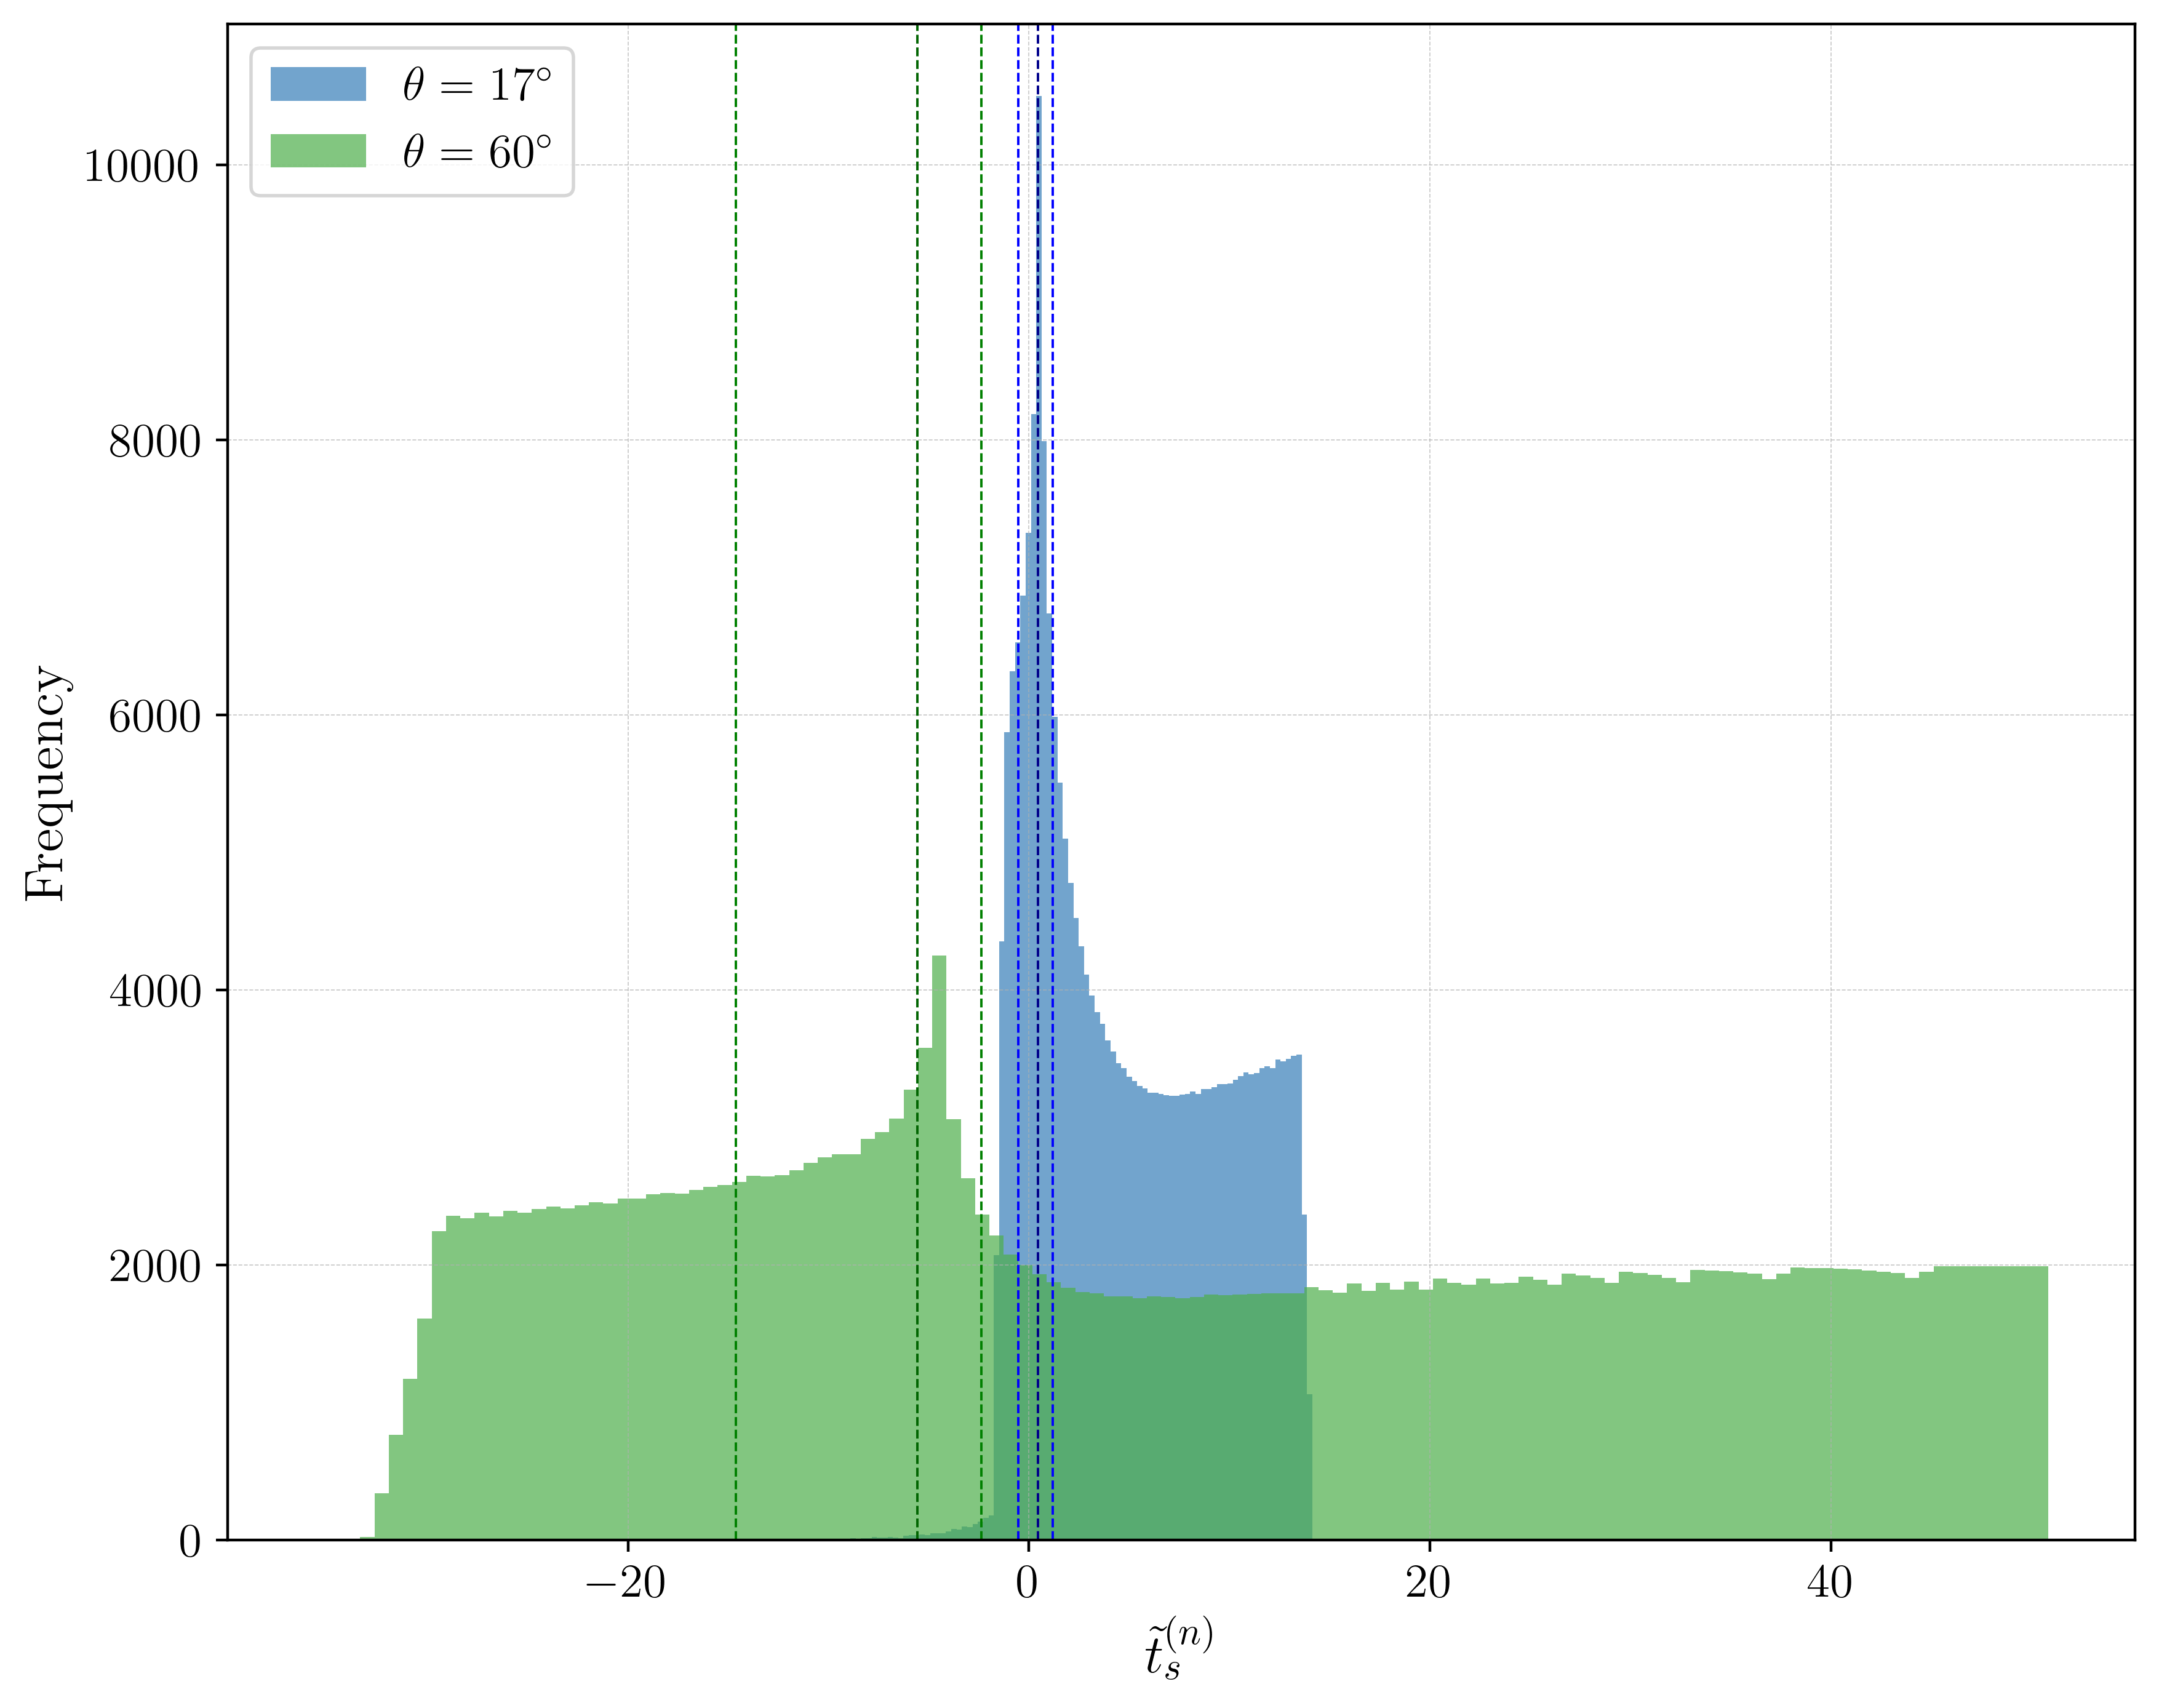

In [33]:
# Create the normalized histogram
plt.figure(figsize=[10,8], dpi=400)

#peso_17 = np.ones_like(t_renorm_17) / N17_live0
#peso_60 = np.ones_like(t_renorm_60) / N60_live0

plt.hist(t0_renorm_17, bins=bins0_17, color='#377eb8', label=r"$\theta = 17^{\circ}$", density=False, alpha=0.7)
#plt.axvline(x=np.min(datos_filtrados_por_bins_17), color='red', linestyle='--', linewidth=0.7)
#plt.axvline(x=np.max(datos_filtrados_por_bins_17), color='red', linestyle='--', linewidth=0.7)
plt.axvline(x=right0_17, color='blue', linestyle='--', linewidth=0.7)
plt.axvline(x=left0_17, color='blue', linestyle='--', linewidth=0.7)
plt.axvline(x=mode0_17, color='darkblue', linestyle='--', linewidth=0.7)


plt.hist(t0_renorm_60, bins=120, color='#4daf4a', label=r"$\theta = 60^{\circ}$", density=False, alpha=0.7)
#plt.axvline(x=np.min(datos_filtrados_por_bins_60), color='red', linestyle='--', linewidth=0.7)
#plt.axvline(x=np.max(datos_filtrados_por_bins_60), color='red', linestyle='--', linewidth=0.7)
plt.axvline(x=right0_60, color='green', linestyle='--', linewidth=0.7)
plt.axvline(x=left0_60, color='green', linestyle='--', linewidth=0.7)
plt.axvline(x=mode0_60, color='darkgreen', linestyle='--', linewidth=0.7)


plt.grid(True, linestyle='--', alpha=0.7, linewidth=0.3)

plt.legend(loc='upper left', fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.xlabel(r'$\tilde{t}_s^{(n)}$', fontsize=16)
plt.ylabel(r'$\mathrm{Frequency}$', fontsize=16)

plt.savefig(path_images + rf"\HistoGrama_origi_total.png",dpi=400,bbox_inches='tight')

plt.show()

In [37]:
p_b = 0.2
mode0, left0, right0, _, mass00, _ = obsint.modal_hdi_kde(t0_17, p_b)
mode1, left1, right1, _, mass01, _ = obsint.modal_hdi_kde(t1_17, p_b)
mode2, left2, right2, _, mass02, _ = obsint.modal_hdi_kde(t2_17, p_b)

In [38]:
minV = 5
maxV = 99.95

t1_renorm_17 = t1_17
valid_mask = np.isfinite(t1_renorm_17)
t1_renorm_17 = t1_renorm_17[valid_mask]
T1min17, T1max17 = np.percentile(t1_renorm_17, [minV,maxV])
mask_in_range_17 = (t1_renorm_17 >= T1min17) & (t1_renorm_17 <= T1max17 )
t1_renorm_17 = t1_renorm_17[mask_in_range_17]

t2_renorm_17 = t2_17
valid_mask = np.isfinite(t2_renorm_17)
t2_renorm_17 = t2_renorm_17[valid_mask]
T2min17, T2max17 = np.percentile(t2_renorm_17, [minV,maxV])
mask_in_range_17 = (t2_renorm_17 >= T2min17) & (t2_renorm_17 <= T2max17 )
t2_renorm_17 = t2_renorm_17[mask_in_range_17]

In [39]:
bins0_17 = freedman_diaconis_bins(t0_renorm_17)
bins1_17 = freedman_diaconis_bins(t1_renorm_17)
bins2_17 = freedman_diaconis_bins(t2_renorm_17)
print("bins n=0 con 17°",bins0_17,",bins n=1 con 17°",bins1_17,",bins n=2 con 17°",bins2_17)

bins n=0 con 17° 188 ,bins n=1 con 17° 83 ,bins n=2 con 17° 36


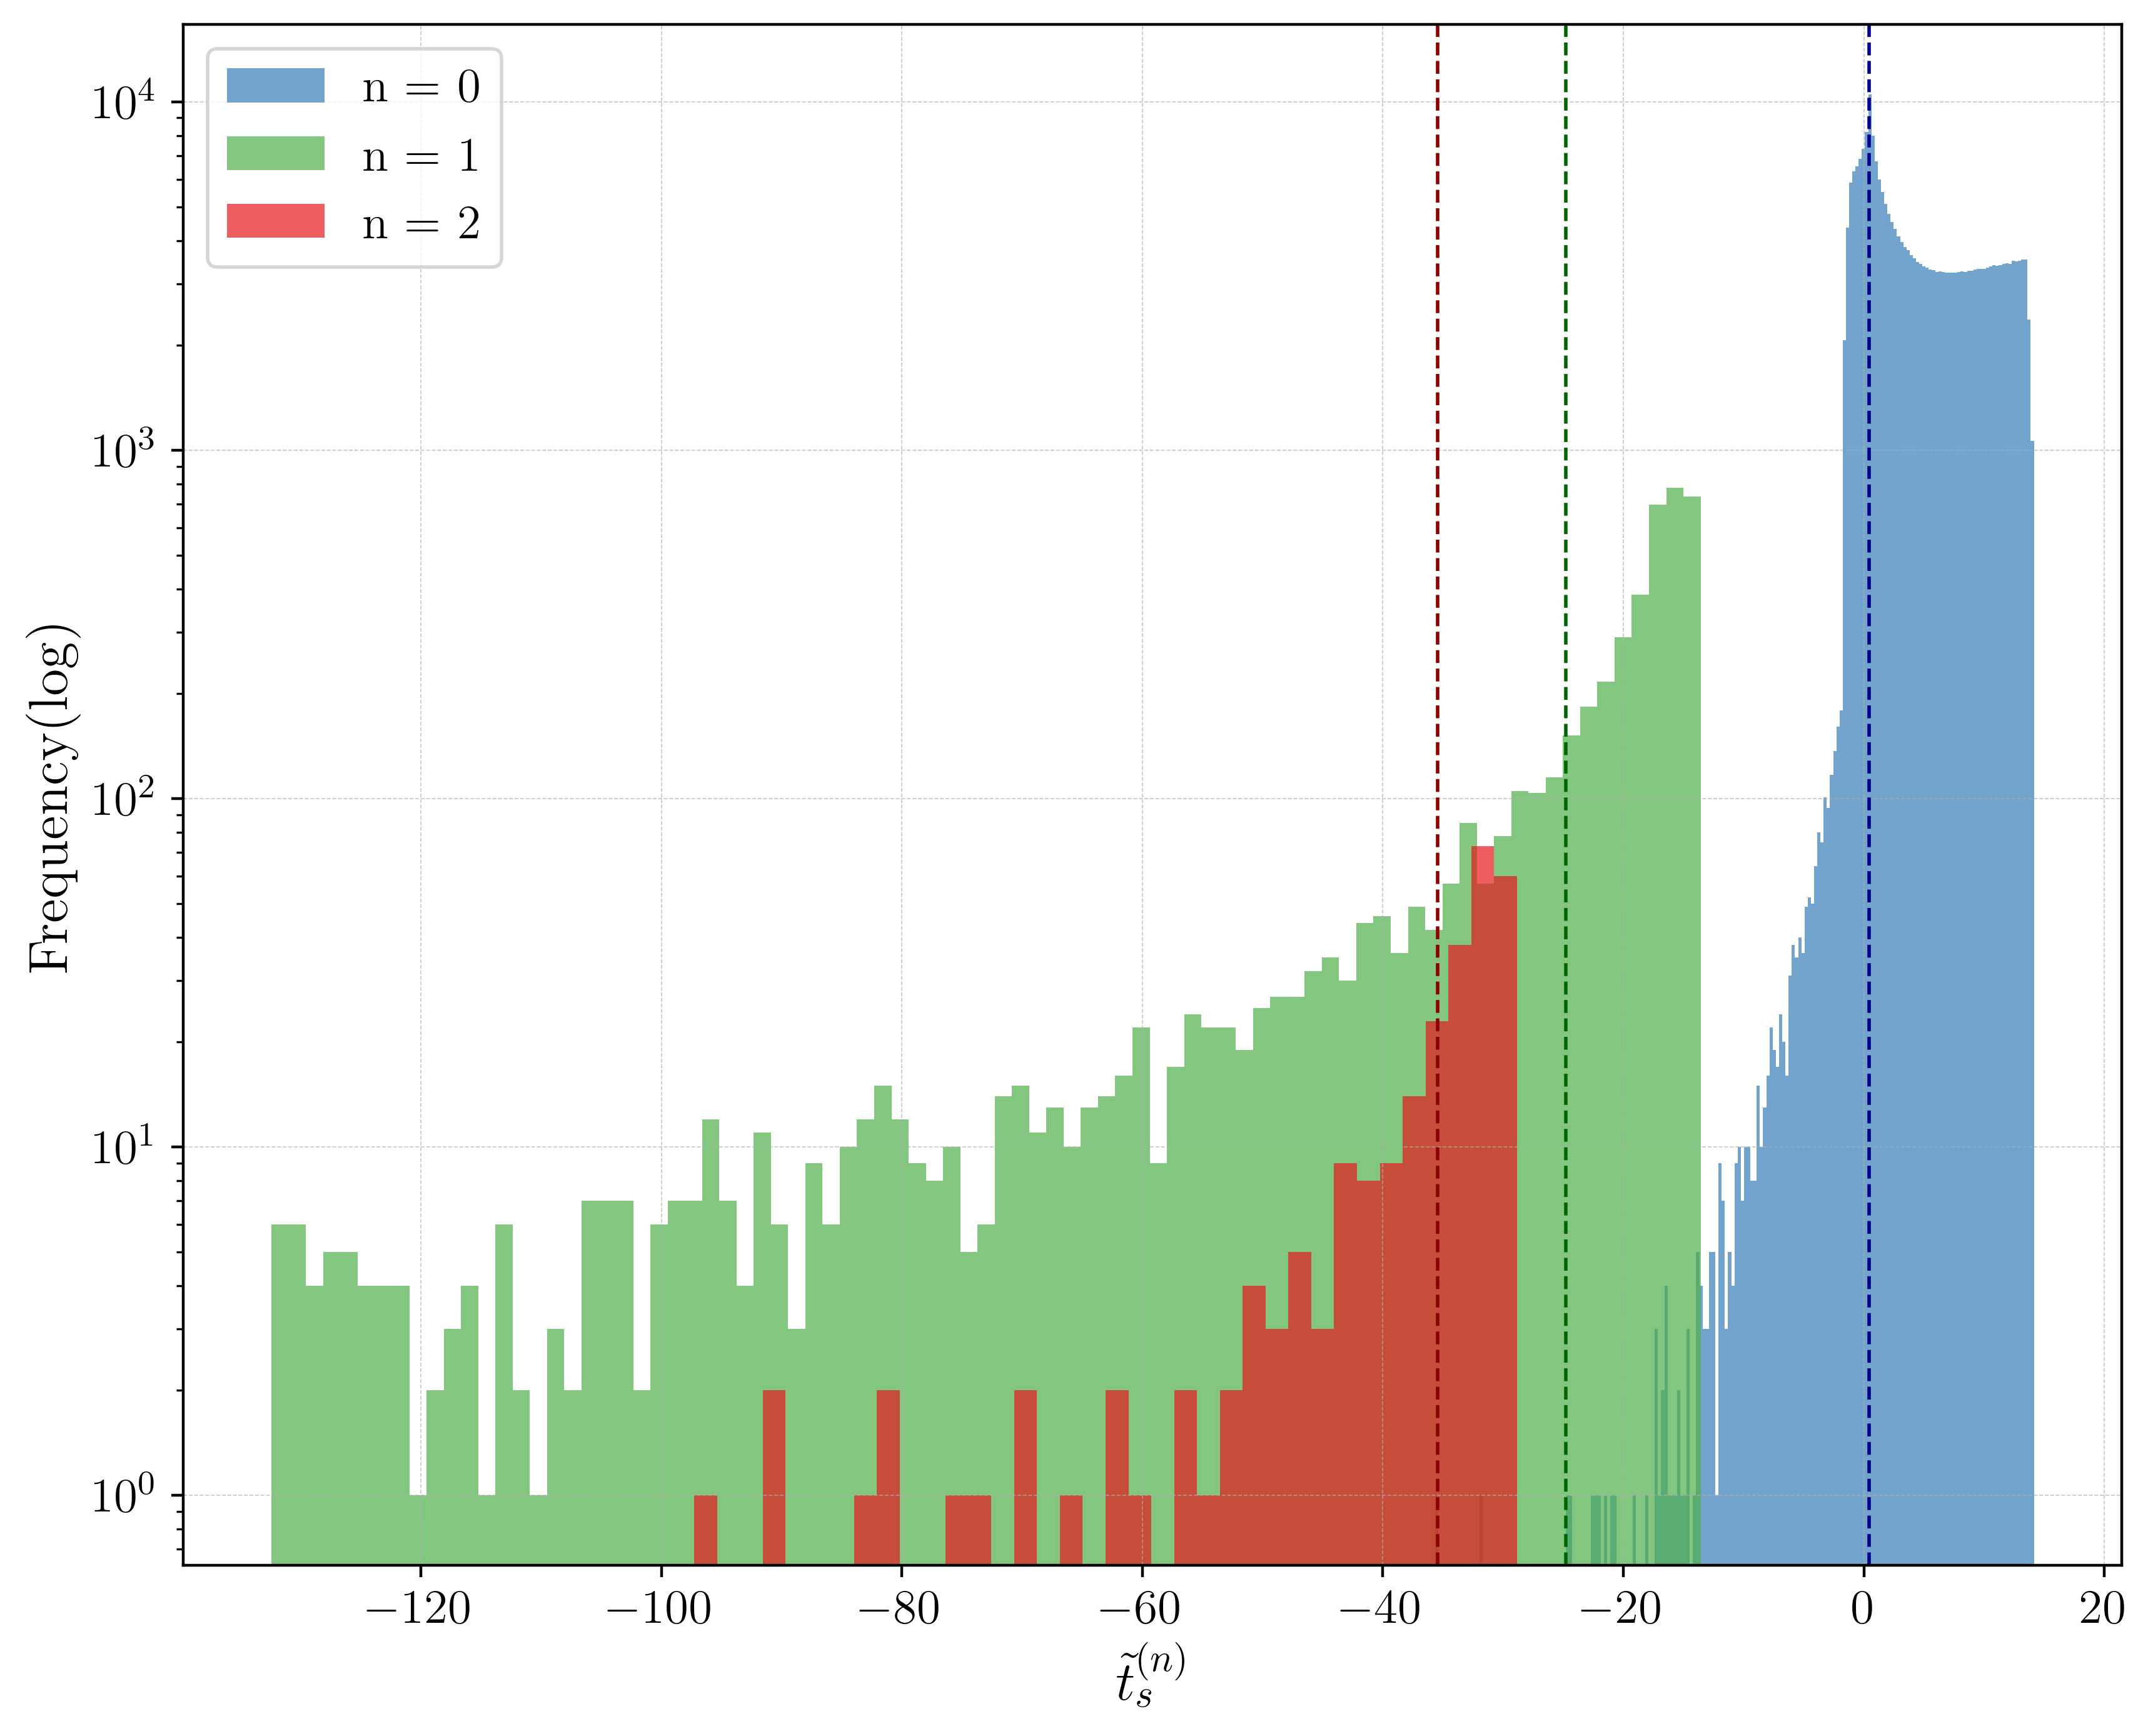

In [45]:
# Create the normalized histogram
plt.figure(figsize=[10,8], dpi=400)


plt.hist(t0_renorm_17, bins=bins0_17, color='#377eb8', label=r"n = 0", density=False, alpha=0.7)
plt.axvline(x=mode0, color='darkblue', linestyle='--', linewidth=1)


plt.hist(t1_renorm_17, bins=bins1_17, color='#4daf4a', label=r"n = 1", density=False, alpha=0.7)
plt.axvline(x=mode1, color='darkgreen', linestyle='--', linewidth=1)


plt.hist(t2_renorm_17, bins=bins2_17, color='#e41a1c', label=r"n = 2", density=False, alpha=0.7)
plt.axvline(x=mode2, color='darkred', linestyle='--', linewidth=1)


plt.grid(True, linestyle='--', alpha=0.7, linewidth=0.3)

plt.yscale("log")
plt.legend(loc='upper left', fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.xlabel(r'$\tilde{t}_s^{(n)}$', fontsize=16)
#plt.xlim(-150,20)
plt.ylabel(r'$\mathrm{Frequency} (\log)$', fontsize=16)
plt.savefig(path_images + rf"\HistoGrama_i17_log_total.png",dpi=400,bbox_inches='tight')
plt.show()

# IV. Variability in Emision Modes

# V. Brisk Light

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import pandas as pd
plt.rcParams['text.usetex'] = True  # Si tienes LaTeX instalado
plt.rcParams['font.family'] = 'serif'

In [3]:
path17_00 = rf"C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\BriskLightResults\B_LightCurve_datas_p0_dx0.1_dt0.6103515625_dtM0.6103515625_a0.94_i17_inoisy_n0.4_i0.94_ft5000_spatial512_snap8192.csv"
path17_02 = rf"C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\BriskLightResults\B_LightCurve_datas_p0.2_dx0.1_dt0.6103515625_dtM0.6103515625_a0.94_i17_inoisy_n0.4_i0.94_ft5000_spatial512_snap8192.csv"
path17_05 = rf"C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\BriskLightResults\B_LightCurve_datas_p0.5_dx0.1_dt0.6103515625_dtM0.6103515625_a0.94_i17_inoisy_n0.4_i0.94_ft5000_spatial512_snap8192.csv"
path17_sf = rf"C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\BriskLightResults\FS_LightCurve_datas_p0_dx0.1_dt0.6103515625_dtM0.6103515625_a0.94_i17_inoisy_n0.4_i0.94_ft5000_spatial512_snap8192.csv"

path60_00 = rf"C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\BriskLightResults\B_LightCurve_datas_p0_dx0.1_dt0.6103515625_dtM0.6103515625_a0.94_i60_inoisy_n0.4_i0.94_ft5000_spatial512_snap8192.csv"
path60_02 = rf"C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\BriskLightResults\B_LightCurve_datas_p0.2_dx0.1_dt0.6103515625_dtM0.6103515625_a0.94_i60_inoisy_n0.4_i0.94_ft5000_spatial512_snap8192.csv"
path60_05 = rf"C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\BriskLightResults\B_LightCurve_datas_p0.5_dx0.1_dt0.6103515625_dtM0.6103515625_a0.94_i60_inoisy_n0.4_i0.94_ft5000_spatial512_snap8192.csv"
path60_sf = rf"C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\BriskLightResults\FS_LightCurve_datas_p0_dx0.1_dt0.6103515625_dtM0.6103515625_a0.94_i60_inoisy_n0.4_i0.94_ft5000_spatial512_snap8192.csv"


LC17_data00 = pd.read_csv(path17_00)
LC17_data02 = pd.read_csv(path17_02)
LC17_data05 = pd.read_csv(path17_05)
LC17_datasf = pd.read_csv(path17_sf)

LC60_data00 = pd.read_csv(path60_00)
LC60_data02 = pd.read_csv(path60_02)
LC60_data05 = pd.read_csv(path60_05)
LC60_datasf = pd.read_csv(path60_sf)

In [100]:
LC17_datasf

,Inoisy data,FastLight n=0,SlowLight n=0,FastLight n=1,SlowLight n=1,FastLight n=2,SlowLight n=2,FastLight,SlowLight,Time
0,113.564925,2814.552917,2790.961932,342.655237,389.996594,20.836029,22.141822,3178.044183,3203.100349,0.000000
1,115.277745,2812.853031,2781.452943,348.477175,386.583214,21.524549,24.639652,3182.854756,3192.675808,0.610426
2,115.294462,2808.277646,2774.698868,350.787803,385.221423,21.680478,26.219485,3180.745927,3186.139776,1.220852
3,114.363482,2797.387902,2769.054965,350.602030,384.182109,21.715169,26.044884,3169.705101,3179.281958,1.831278
4,114.106854,2788.885996,2763.143669,347.410473,387.376292,21.465280,25.363373,3157.761749,3175.883334,2.441704
...,...,...,...,...,...,...,...,...,...,...
8187,120.942334,2873.408710,2827.464777,349.156432,369.227684,20.045382,17.544920,3242.610523,3214.237381,4997.558296
8188,118.446690,2860.923026,2816.852219,343.168788,375.921990,19.819306,18.112380,3223.911120,3210.886589,4998.168722
8189,116.572613,2845.496993,2805.902518,337.593566,387.141295,19.596078,18.903093,3202.686637,3211.946905,4998.779148
8190,116.205617,2835.630088,2798.376826,334.124986,390.951390,19.618606,20.184727,3189.373680,3209.512943,4999.389574


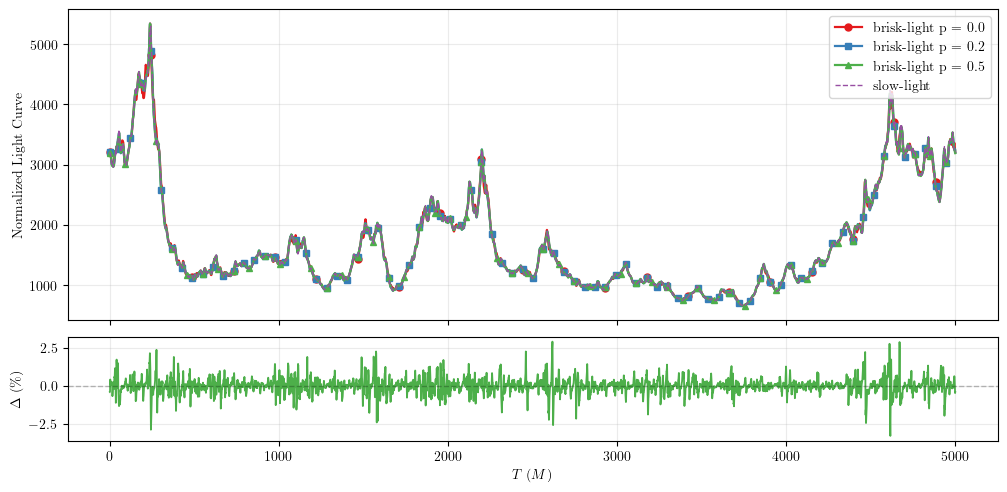

In [5]:
# ============================================================
# VARIABLES (ya cargadas por ti)
# ============================================================
Time       = LC17_datasf["Time"]
LC_slow    = LC17_datasf["SlowLight"]
LC_brisk_1 = LC17_data00["BriskLight"]
LC_brisk_2 = LC17_data02["BriskLight"]
LC_brisk_3 = LC17_data05["BriskLight"]

Time = np.asarray(Time)
LC_slow = np.asarray(LC_slow)
LC_brisk_1 = np.asarray(LC_brisk_1)
LC_brisk_2 = np.asarray(LC_brisk_2)
LC_brisk_3 = np.asarray(LC_brisk_3)

if not (len(Time) == len(LC_slow) == len(LC_brisk_1) == len(LC_brisk_2) == len(LC_brisk_3)):
    raise ValueError("Todas las series deben tener la misma longitud.")

# ============================================================
# ERROR RELATIVO (%)
# ============================================================
eps = 1e-15
mask = np.abs(LC_slow) > eps

rel_err_1 = np.full_like(LC_slow, np.nan, dtype=float)
rel_err_2 = np.full_like(LC_slow, np.nan, dtype=float)
rel_err_3 = np.full_like(LC_slow, np.nan, dtype=float)

rel_err_1[mask] = 100.0 * (LC_brisk_1[mask] - LC_slow[mask]) / LC_slow[mask]
rel_err_2[mask] = 100.0 * (LC_brisk_2[mask] - LC_slow[mask]) / LC_slow[mask]
rel_err_3[mask] = 100.0 * (LC_brisk_3[mask] - LC_slow[mask]) / LC_slow[mask]

# ============================================================
# FIGURA
# ============================================================
fig = plt.figure(figsize=(12, 5.6))
gs = GridSpec(2, 1, height_ratios=[3, 1], hspace=0.08)

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharex=ax1)

# --- Curvas ---
ax1.plot(Time, LC_brisk_1, lw=1.6, label="brisk-light p = 0.0",color="#e41a1c", marker="o",markersize=5,markevery=400)
ax1.plot(Time, LC_brisk_2, lw=1.6, label="brisk-light p = 0.2",color="#377eb8",marker="s",markersize=5,markevery=100)
ax1.plot(Time, LC_brisk_3, lw=1.6, label="brisk-light p = 0.5",color="#4daf4a",marker="^",markersize=5,markevery=150)
ax1.plot(Time, LC_slow, "--", lw=1, label="slow-light",color="#984ea3")

ax1.set_ylabel("Normalized Light Curve")
ax1.legend(loc="upper right", frameon=True)
ax1.grid(True, alpha=0.25)

ax1.tick_params(axis='x', which='both', labelbottom=False)
# --- Error relativo ---
#ax2.plot(Time, rel_err_1, lw=1.3,color="#e41a1c")
#ax2.plot(Time, rel_err_2, lw=1.3,color="#377eb8")
ax2.plot(Time, rel_err_3, lw=1.3,color="#4daf4a")
ax2.axhline(0, lw=1.0, ls="--", color="black",alpha=0.25)

ax2.set_xlabel(r"$T\ (M)$")
ax2.set_ylabel(r"$\Delta\ (\%)$")
ax2.grid(True, alpha=0.25)

# ============================================================
# GUARDADO
# ============================================================
out_dir = "plots_lightcurves"
os.makedirs(out_dir, exist_ok=True)

fname = os.path.join(out_dir, "lightcurve_brisk_vs_slow.png")

#fig.savefig(
#    fname,
#    dpi=300,
#    bbox_inches="tight",   # evita recortes
#    facecolor="white"
#)
plt.show()
plt.close(fig)


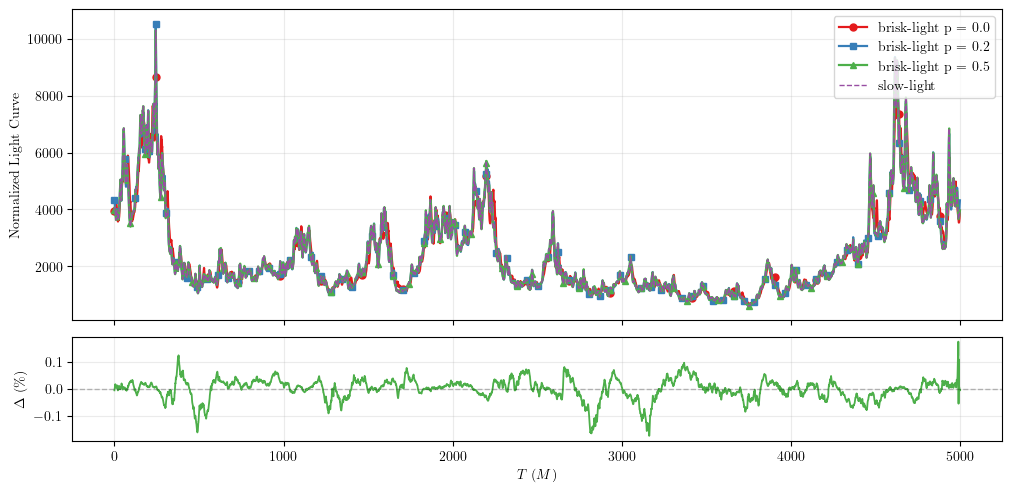

In [7]:
# ============================================================
# VARIABLES (ya cargadas por ti)
# ============================================================
Time       = LC60_datasf["Time"]
LC_slow    = LC60_datasf["SlowLight"]
LC_brisk_1 = LC60_data00["BriskLight"]
LC_brisk_2 = LC60_data02["BriskLight"]
LC_brisk_3 = LC60_data05["BriskLight"]

Time = np.asarray(Time)
LC_slow = np.asarray(LC_slow)
LC_brisk_1 = np.asarray(LC_brisk_1)
LC_brisk_2 = np.asarray(LC_brisk_2)
LC_brisk_3 = np.asarray(LC_brisk_3)

if not (len(Time) == len(LC_slow) == len(LC_brisk_1) == len(LC_brisk_2) == len(LC_brisk_3)):
    raise ValueError("Todas las series deben tener la misma longitud.")

# ============================================================
# ERROR RELATIVO (%)
# ============================================================
eps = 1e-15
mask = np.abs(LC_slow) > eps

rel_err_1 = np.full_like(LC_slow, np.nan, dtype=float)
rel_err_2 = np.full_like(LC_slow, np.nan, dtype=float)
rel_err_3 = np.full_like(LC_slow, np.nan, dtype=float)

rel_err_1[mask] = 100.0 * (LC_brisk_1[mask] - LC_slow[mask]) / LC_slow[mask]
rel_err_2[mask] = 100.0 * (LC_brisk_2[mask] - LC_slow[mask]) / LC_slow[mask]
rel_err_3[mask] = 100.0 * (LC_brisk_3[mask] - LC_slow[mask]) / LC_slow[mask]

# ============================================================
# FIGURA
# ============================================================
fig = plt.figure(figsize=(12, 5.6))
gs = GridSpec(2, 1, height_ratios=[3, 1], hspace=0.08)

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharex=ax1)

# --- Curvas ---
ax1.plot(Time, LC_brisk_1, lw=1.6, label="brisk-light p = 0.0",color="#e41a1c", marker="o",markersize=5,markevery=400)
ax1.plot(Time, LC_brisk_2, lw=1.6, label="brisk-light p = 0.2",color="#377eb8",marker="s",markersize=5,markevery=100)
ax1.plot(Time, LC_brisk_3, lw=1.6, label="brisk-light p = 0.5",color="#4daf4a",marker="^",markersize=5,markevery=150)
ax1.plot(Time, LC_slow, "--", lw=1, label="slow-light",color="#984ea3")

ax1.set_ylabel("Normalized Light Curve")
ax1.legend(loc="upper right", frameon=True)
ax1.grid(True, alpha=0.25)

ax1.tick_params(axis='x', which='both', labelbottom=False)
# --- Error relativo ---
#ax2.plot(Time, rel_err_1, lw=1.3,color="#e41a1c")
#ax2.plot(Time, rel_err_2, lw=1.3,color="#377eb8")
ax2.plot(Time, rel_err_3, lw=1.3,color="#4daf4a")
ax2.axhline(0, lw=1.0, ls="--", color="black",alpha=0.25)


ax2.set_xlabel(r"$T\ (M)$")
ax2.set_ylabel(r"$\Delta\ (\%)$")
ax2.grid(True, alpha=0.25)

# ============================================================
# GUARDADO
# ============================================================
out_dir = "plots_lightcurves"
os.makedirs(out_dir, exist_ok=True)

fname = os.path.join(out_dir, "lightcurve_brisk_vs_slow.png")

#fig.savefig(
#    fname,
#    dpi=300,
#    bbox_inches="tight",   # evita recortes
#    facecolor="white"
#)
plt.show()
plt.close(fig)

In [56]:
def crear_tabla_metricas_brisk(df_brisk0, df_brisk1, df_brisk2, df_sf):
    """
    Compara tres datasets Brisk contra SlowLight y FastLight,
    e incluye comparación base Slow vs Fast
    """

    import numpy as np
    import pandas as pd

    slice_ = slice(100, -100)
    resultados = []

    # Eje común
    x = df_sf['Time'].to_numpy()[slice_]

    # Referencias
    slow = df_sf['SlowLight'].to_numpy()[slice_]
    fast = df_sf['FastLight'].to_numpy()[slice_]

    # -------- Slow vs Fast (BASELINE) --------
    l2_sf = distancia_L2_rel(slow, fast, x)
    l1_sf = distancia_L1_rel(slow, fast, x)

    resultados.append({
        'Comparación': 'Slow vs Fast',
        'Distancia L²': l2_sf,
        'Distancia L¹': l1_sf
    })

    # Agrupar los brisk
    brisks = [
        ('Brisk m=0.0', df_brisk0),
        ('Brisk m=0.2', df_brisk1),
        ('Brisk m=0.5', df_brisk2)
    ]

    for nombre, df_brisk in brisks:

        brisk = df_brisk['BriskLight'].to_numpy()[slice_]

        # -------- Brisk vs Slow --------
        l2_slow = distancia_L2_rel(brisk, slow, x)
        l1_slow = distancia_L1_rel(brisk, slow, x)

        resultados.append({
            'Comparación': f'{nombre} vs Slow',
            'Distancia L²': l2_slow,
            'Distancia L¹': l1_slow
        })

        # -------- Brisk vs Fast --------
        l2_fast = distancia_L2_rel(brisk, fast, x)
        l1_fast = distancia_L1_rel(brisk, fast, x)

        resultados.append({
            'Comparación': f'{nombre} vs Fast',
            'Distancia L²': l2_fast,
            'Distancia L¹': l1_fast
        })

    return pd.DataFrame(resultados)

In [58]:
crear_tabla_metricas_brisk(LC17_data00,LC17_data02,LC17_data05,LC17_datasf)

,Comparación,Distancia L²,Distancia L¹
0,Slow vs Fast,0.027622,0.019489
1,Brisk m=0.0 vs Slow,0.024004,0.016357
2,Brisk m=0.0 vs Fast,0.028335,0.020064
3,Brisk m=0.2 vs Slow,0.010213,0.006544
4,Brisk m=0.2 vs Fast,0.022878,0.016095
5,Brisk m=0.5 vs Slow,0.006253,0.003709
6,Brisk m=0.5 vs Fast,0.024278,0.017203


In [60]:
crear_tabla_metricas_brisk(LC60_data00,LC60_data02,LC60_data05,LC60_datasf)

,Comparación,Distancia L²,Distancia L¹
0,Slow vs Fast,0.115647,0.081184
1,Brisk m=0.0 vs Slow,0.106358,0.079033
2,Brisk m=0.0 vs Fast,0.150028,0.111687
3,Brisk m=0.2 vs Slow,0.017786,0.012770
4,Brisk m=0.2 vs Fast,0.118585,0.082564
5,Brisk m=0.5 vs Slow,0.000260,0.000233
6,Brisk m=0.5 vs Fast,0.115644,0.081179


In [14]:
def crear_tabla_metricas_simple(df_brisk, df_sf):
    """
    Compara:
    - Brisk vs Slow
    - Slow vs Fast

    Parámetros:
    df_brisk: DataFrame con columnas [BriskLight, Time]
    df_sf: DataFrame con columnas [FastLight, SlowLight, Time]

    Returns:
    DataFrame con columnas: Comparación, Distancia L², Distancia L¹
    """

    slice_ = slice(100, -100)

    # Extraer datos
    brisk = df_brisk['BriskLight'].to_numpy()[slice_]
    slow = df_sf['SlowLight'].to_numpy()[slice_]
    fast = df_sf['FastLight'].to_numpy()[slice_]
    x = df_sf['Time'].to_numpy()[slice_]

    resultados = []

    # -------- Brisk vs Slow --------
    l2_bs = np.sqrt(simpson((brisk - slow)**2, x))
    l1_bs = simpson(np.abs(brisk - slow), x)

    resultados.append({
        'Comparación': 'Brisk vs Slow',
        'Distancia L²': l2_bs,
        'Distancia L¹': l1_bs
    })

    # -------- Slow vs Fast --------
    l2_sf = np.sqrt(simpson((slow - fast)**2, x))
    l1_sf = simpson(np.abs(slow - fast), x)

    resultados.append({
        'Comparación': 'Slow vs Fast',
        'Distancia L²': l2_sf,
        'Distancia L¹': l1_sf
    })

    return pd.DataFrame(resultados)

In [16]:
crear_tabla_metricas_simple(LC17_data00,LC17_datasf)

,Comparación,Distancia L²,Distancia L¹
0,Brisk vs Slow,3095.095916,131208.904734
1,Slow vs Fast,3563.815322,156314.053975


In [18]:
crear_tabla_metricas_simple(LC60_data00,LC60_datasf)

,Comparación,Distancia L²,Distancia L¹
0,Brisk vs Slow,20145.536347,887993.138675
1,Slow vs Fast,22039.290262,911463.724787


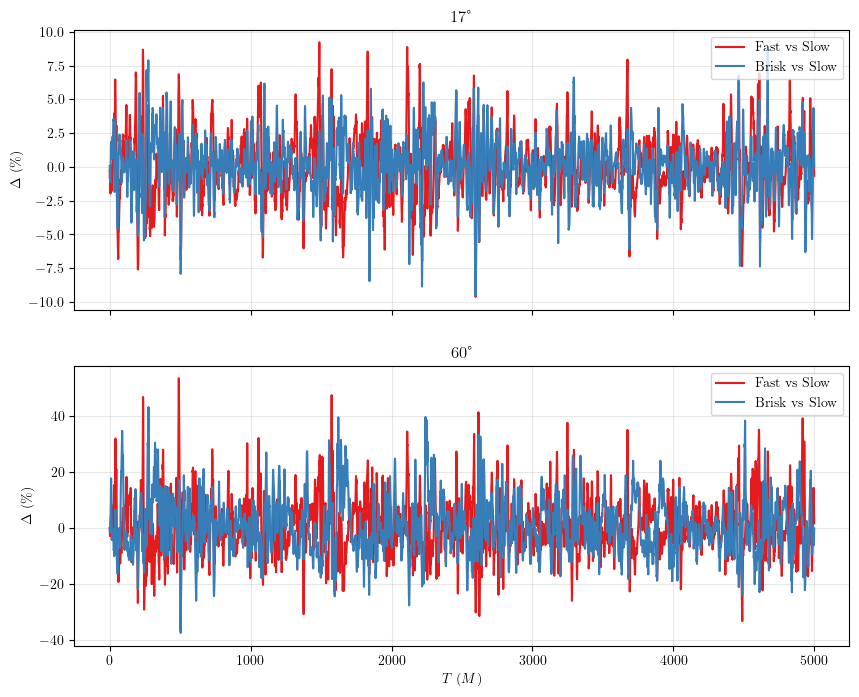

In [38]:
# ==============================
# VARIABLES EDITABLES
# ==============================
inc1 = 17   # inclinación arriba
inc2 = 60   # inclinación abajo

label_fast = "Fast"
label_slow = "Slow"
label_brisk = "Brisk"

# ==============================
# SUPONIENDO QUE YA TIENES ESTO
# ==============================
x = LC17_datasf["Time"]
slow_17, fast_17, brisk_17 = LC17_datasf["SlowLight"],LC17_datasf["FastLight"], LC17_data00["BriskLight"]
slow_60, fast_60, brisk_60 =LC60_datasf["SlowLight"],LC60_datasf["FastLight"], LC60_data00["BriskLight"]

# ==============================
# DIFERENCIAS PUNTO A PUNTO
# ==============================
diff_fast_slow_17 = (FluxFactor(fast_17) - FluxFactor(slow_17)) / FluxFactor(slow_17)  *100
diff_brisk_slow_17 = (FluxFactor(brisk_17) - FluxFactor(slow_17)) / FluxFactor(slow_17)  *100

diff_fast_slow_60 = (FluxFactor(fast_60) - FluxFactor(slow_60)) / FluxFactor(slow_60)  *100
diff_brisk_slow_60 = (FluxFactor(brisk_60) - FluxFactor(slow_60)) / FluxFactor(slow_60)  *100

# ==============================
# FIGURA
# ==============================
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# ---- Arriba (17°) ----
axes[0].plot(x, diff_fast_slow_17, label=f'{label_fast} vs {label_slow} ',color="#e41a1c")
axes[0].plot(x, diff_brisk_slow_17, label=f'{label_brisk} vs {label_slow} ',color="#377eb8")

axes[0].set_title(f'{inc1}°')
axes[0].set_ylabel(r"$\Delta\ (\%)$")
axes[0].legend()
axes[0].grid(alpha=0.3)

# ---- Abajo (60°) ----
axes[1].plot(x, diff_fast_slow_60, label=f'{label_fast} vs {label_slow} ',color="#e41a1c")
axes[1].plot(x, diff_brisk_slow_60, label=f'{label_brisk} vs {label_slow} ',color="#377eb8")
axes[1].set_title(f' {inc2}°')
axes[1].set_xlabel(r"$T\ (M)$")
axes[1].set_ylabel(r"$\Delta\ (\%)$")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.show()

🎯 Demo: Comparación de imágenes con NMSE global
✅ Imágenes creadas: tamaño 100x100 pixeles

📊 Resultados NMSE:
   Slow vs Fast:  3.511851e-01
   Slow vs Brisk: 7.817612e-01
   Fast vs Brisk: 3.002674e+00


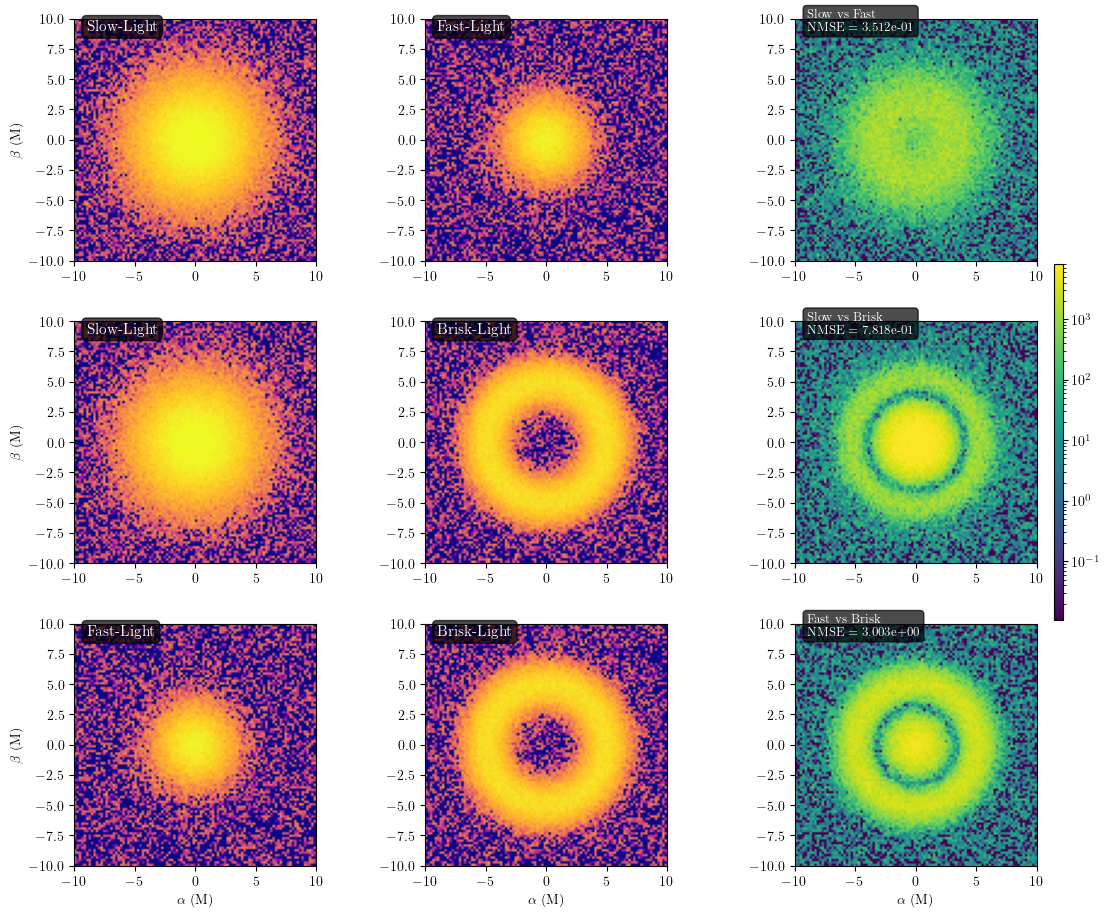


✅ Visualización completada!
   - Títulos dentro de las imágenes (labels con fondo negro)
   - Una sola colorbar para todas las diferencias
   - Sin título principal


In [163]:
from matplotlib.colors import LogNorm

print("🎯 Demo: Comparación de imágenes con NMSE global")

# ============================================================
# CREAR IMÁGENES ALEATORIAS QUE SIMULAN TUS DATOS
# ============================================================
np.random.seed(42)  # Para resultados reproducibles

# Tamaño de las imágenes (simulando un grid 100x100)
size = 100
extent = [-10, 10, -10, 10]

# Crear coordenadas para dar estructura realista a las imágenes
x = np.linspace(-10, 10, size)
y = np.linspace(-10, 10, size)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)

# IMAGEN SLOW (luz lenta) - Gaussiana ancha + ruido
img_s = 100 * np.exp(-R**2 / 20) + np.random.normal(0, 5, (size, size))
img_s = np.maximum(img_s, 0.1)  # Evitar ceros para LogNorm

# IMAGEN FAST (luz rápida) - Gaussiana estrecha + ruido
img_f = 80 * np.exp(-R**2 / 8) + np.random.normal(0, 5, (size, size))
img_f = np.maximum(img_f, 0.1)

# IMAGEN BRISK (luz vivaz) - Anillo + ruido
img_b = 60 * np.exp(-((R-5)**2) / 3) + np.random.normal(0, 5, (size, size))
img_b = np.maximum(img_b, 0.1)

print(f"✅ Imágenes creadas: tamaño {size}x{size} pixeles")

# ============================================================
# FUNCIÓN: CALCULA NMSE GLOBAL
# ============================================================
def calculate_nmse(img_a, img_b):
    """Calcula NMSE global: sum((a-b)^2) / sum(a^2)"""
    denominador = np.sum(img_a**2)
    if denominador == 0:
        return np.inf
    return np.sum((img_a - img_b)**2) / denominador

# ============================================================
# CALCULAR NMSE PARA CADA PAR
# ============================================================
nmse_sf = calculate_nmse(img_s, img_f)  # Slow vs Fast
nmse_sb = calculate_nmse(img_s, img_b)  # Slow vs Brisk
nmse_fb = calculate_nmse(img_f, img_b)  # Fast vs Brisk

print(f"\n📊 Resultados NMSE:")
print(f"   Slow vs Fast:  {nmse_sf:.6e}")
print(f"   Slow vs Brisk: {nmse_sb:.6e}")
print(f"   Fast vs Brisk: {nmse_fb:.6e}")

# ============================================================
# MAPAS DE DIFERENCIA (para visualizar)
# ============================================================
diff_sf = (img_s - img_f)**2
diff_sb = (img_s - img_b)**2
diff_fb = (img_f - img_b)**2

# Escala común para los mapas de diferencia
all_diff = np.concatenate([diff_sf.ravel(), diff_sb.ravel(), diff_fb.ravel()])
pos_diff = all_diff[all_diff > 0]
eps = 1e-12
if len(pos_diff) > 0:
    DMIN = max(np.percentile(pos_diff, 1), eps)
    DMAX = np.percentile(pos_diff, 99.5)
else:
    DMIN, DMAX = eps, 1.0

# ============================================================
# ESCALA PARA IMÁGENES FÍSICAS
# ============================================================
all_imgs = np.concatenate([img_s.ravel(), img_f.ravel(), img_b.ravel()])
positive_mask = all_imgs > 0
VMAX = np.percentile(all_imgs, 99.5)
VMIN = max(np.percentile(all_imgs[positive_mask], 1), eps)

# ============================================================
# CREAR FIGURA 3x3
# ============================================================
fig, axes = plt.subplots(3, 3, figsize=(13, 11))

# FILA 1: Slow | Fast | Diferencia
im00 = axes[0,0].imshow(img_s + eps, origin='lower', cmap='plasma', 
                        extent=extent, norm=LogNorm(vmin=VMIN, vmax=VMAX))
axes[0,0].text(0.05, 0.95, 'Slow-Light', transform=axes[0,0].transAxes, 
               fontsize=11, fontweight='bold', color='white', 
               bbox=dict(boxstyle="round,pad=0.3", facecolor='black', alpha=0.7))
axes[0,0].set_ylabel(r'$\beta$ (M)')

axes[0,1].imshow(img_f + eps, origin='lower', cmap='plasma', 
                 extent=extent, norm=LogNorm(vmin=VMIN, vmax=VMAX))
axes[0,1].text(0.05, 0.95, 'Fast-Light', transform=axes[0,1].transAxes, 
               fontsize=11, fontweight='bold', color='white', 
               bbox=dict(boxstyle="round,pad=0.3", facecolor='black', alpha=0.7))

im02 = axes[0,2].imshow(diff_sf + eps, origin='lower', cmap='viridis', 
                        extent=extent, norm=LogNorm(vmin=DMIN, vmax=DMAX))
axes[0,2].text(0.05, 0.95, f'Slow vs Fast\nNMSE = {nmse_sf:.3e}', 
               transform=axes[0,2].transAxes, fontsize=9, color='white', 
               bbox=dict(boxstyle="round,pad=0.3", facecolor='black', alpha=0.7))

# FILA 2: Slow | Brisk | Diferencia
axes[1,0].imshow(img_s + eps, origin='lower', cmap='plasma', 
                 extent=extent, norm=LogNorm(vmin=VMIN, vmax=VMAX))
axes[1,0].text(0.05, 0.95, 'Slow-Light', transform=axes[1,0].transAxes, 
               fontsize=11, fontweight='bold', color='white', 
               bbox=dict(boxstyle="round,pad=0.3", facecolor='black', alpha=0.7))
axes[1,0].set_ylabel(r'$\beta$ (M)')

axes[1,1].imshow(img_b + eps, origin='lower', cmap='plasma', 
                 extent=extent, norm=LogNorm(vmin=VMIN, vmax=VMAX))
axes[1,1].text(0.05, 0.95, 'Brisk-Light', transform=axes[1,1].transAxes, 
               fontsize=11, fontweight='bold', color='white', 
               bbox=dict(boxstyle="round,pad=0.3", facecolor='black', alpha=0.7))

im12 = axes[1,2].imshow(diff_sb + eps, origin='lower', cmap='viridis', 
                        extent=extent, norm=LogNorm(vmin=DMIN, vmax=DMAX))
axes[1,2].text(0.05, 0.95, f'Slow vs Brisk\nNMSE = {nmse_sb:.3e}', 
               transform=axes[1,2].transAxes, fontsize=9, color='white', 
               bbox=dict(boxstyle="round,pad=0.3", facecolor='black', alpha=0.7))

# FILA 3: Fast | Brisk | Diferencia
axes[2,0].imshow(img_f + eps, origin='lower', cmap='plasma', 
                 extent=extent, norm=LogNorm(vmin=VMIN, vmax=VMAX))
axes[2,0].text(0.05, 0.95, 'Fast-Light', transform=axes[2,0].transAxes, 
               fontsize=11, fontweight='bold', color='white', 
               bbox=dict(boxstyle="round,pad=0.3", facecolor='black', alpha=0.7))
axes[2,0].set_xlabel(r'$\alpha$ (M)')
axes[2,0].set_ylabel(r'$\beta$ (M)')

axes[2,1].imshow(img_b + eps, origin='lower', cmap='plasma', 
                 extent=extent, norm=LogNorm(vmin=VMIN, vmax=VMAX))
axes[2,1].text(0.05, 0.95, 'Brisk-Light', transform=axes[2,1].transAxes, 
               fontsize=11, fontweight='bold', color='white', 
               bbox=dict(boxstyle="round,pad=0.3", facecolor='black', alpha=0.7))
axes[2,1].set_xlabel(r'$\alpha$ (M)')

im22 = axes[2,2].imshow(diff_fb + eps, origin='lower', cmap='viridis', 
                        extent=extent, norm=LogNorm(vmin=DMIN, vmax=DMAX))
axes[2,2].text(0.05, 0.95, f'Fast vs Brisk\nNMSE = {nmse_fb:.3e}', 
               transform=axes[2,2].transAxes, fontsize=9, color='white', 
               bbox=dict(boxstyle="round,pad=0.3", facecolor='black', alpha=0.7))
axes[2,2].set_xlabel(r'$\alpha$ (M)')

# Configurar límites y aspecto para todas las subplots
for i in range(3):
    for j in range(3):
        axes[i,j].set_xlim(-10, 10)
        axes[i,j].set_ylim(-10, 10)
        axes[i,j].set_facecolor('black')
        axes[i,j].set_aspect('equal')

# ============================================================
# SOLO UNA COLORBAR PARA LAS DIFERENCIAS (tercera columna)
# ============================================================
# Crear una sola colorbar para los mapas de diferencia
cbar_diff = fig.colorbar(im02, ax=axes[:,2], fraction=0.03, pad=0.1, aspect=40)
#cbar_diff.set_label('(a-b)²', fontsize=10)
# Ajustar layout para evitar superposiciones

fig.subplots_adjust(wspace=0.25, hspace=0.25, right=0.88)
# Mostrar la figura
plt.show()

print("\n" + "="*50)
print("✅ Visualización completada!")
print("   - Títulos dentro de las imágenes (labels con fondo negro)")
print("   - Una sola colorbar para todas las diferencias")
print("   - Sin título principal")
print("="*50)

# VI. Conclution